In [15]:
import pandas as pd

file_path = r'C:\Users\Right-click\OneDrive\سطح المكتب\E-commerce-Customers-Segmentation-main\E-commerce_data.xlsx'
transactions = pd.read_excel(file_path, sheet_name='transactions')
customers = pd.read_excel(file_path, sheet_name='customers')
genders = pd.read_excel(file_path, sheet_name='genders')
cities = pd.read_excel(file_path, sheet_name='cities')
branches = pd.read_excel(file_path, sheet_name='branches')
merchants = pd.read_excel(file_path, sheet_name='merchants')

df = transactions.merge(customers, on='customer_id', how='left')
df = df.merge(genders, on='gender_id', how='left')
df = df.merge(cities, on='city_id', how='left')
df = df.merge(branches, on='branch_id', how='left')
df = df.merge(merchants, on='merchant_id', how='left')

df.head()

,transaction_id,customer_id,transaction_date,transaction_status,coupon_name,burn_date_x,branch_id,join_date,city_id,gender_id,burn_date_y,gender_name,city_name,merchant_id,merchant_name
0,1,733,2024-05-11,subscribed,uNY-568,NaT,7,2023-05-16,15,2,NaN,Female,Aswan,7,Berry-Anderson
1,2,631,2023-05-15,burned,kBx-219,2023-06-04,5,2022-10-10,14,2,NaN,Female,Damietta,9,"Campbell, Shaffer and Martinez"
2,3,309,2022-11-13,subscribed,PLG-122,NaT,7,2022-05-30,2,1,NaN,Male,Alexandria,7,Berry-Anderson
3,4,695,2024-01-26,subscribed,Wzf-897,NaT,2,2023-11-27,15,2,NaN,Female,Aswan,18,Lewis LLC
4,5,288,2022-10-12,burned,qGb-428,2022-11-20,6,2021-09-04,14,1,NaN,Male,Damietta,15,Butler-Gomez


In [19]:
for col in df.columns:
    print(col)

transaction_id
customer_id
transaction_date
transaction_status
coupon_name
burn_date
branch_id
join_date
city_id
gender_id
gender_name
city_name
merchant_id
merchant_name


In [18]:
df.rename(columns={'burn_date_x': 'burn_date'}, inplace=True)
df.drop(columns=['burn_date_y'], inplace=True)

## Data Description

In [20]:
print(df.columns)

Index(['transaction_id', 'customer_id', 'transaction_date',
       'transaction_status', 'coupon_name', 'burn_date', 'branch_id',
       'join_date', 'city_id', 'gender_id', 'gender_name', 'city_name',
       'merchant_id', 'merchant_name'],
      dtype='object')


In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   transaction_id      5000 non-null   int64         
 1   customer_id         5000 non-null   int64         
 2   transaction_date    5000 non-null   datetime64[ns]
 3   transaction_status  5000 non-null   object        
 4   coupon_name         5000 non-null   object        
 5   burn_date           2516 non-null   datetime64[ns]
 6   branch_id           5000 non-null   int64         
 7   join_date           5000 non-null   datetime64[ns]
 8   city_id             5000 non-null   int64         
 9   gender_id           5000 non-null   int64         
 10  gender_name         5000 non-null   object        
 11  city_name           5000 non-null   object        
 12  merchant_id         5000 non-null   int64         
 13  merchant_name       5000 non-null   object      

In [22]:
df.dtypes

transaction_id                 int64
customer_id                    int64
transaction_date      datetime64[ns]
transaction_status            object
coupon_name                   object
burn_date             datetime64[ns]
branch_id                      int64
join_date             datetime64[ns]
city_id                        int64
gender_id                      int64
gender_name                   object
city_name                     object
merchant_id                    int64
merchant_name                 object
dtype: object

In [23]:
df.duplicated().sum()

0

In [24]:
df.isnull().sum()

transaction_id           0
customer_id              0
transaction_date         0
transaction_status       0
coupon_name              0
burn_date             2484
branch_id                0
join_date                0
city_id                  0
gender_id                0
gender_name              0
city_name                0
merchant_id              0
merchant_name            0
dtype: int64

In [25]:
df.shape

(5000, 14)

In [26]:
for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique values")

transaction_id: 5000 unique values
customer_id: 989 unique values
transaction_date: 885 unique values
transaction_status: 2 unique values
coupon_name: 5000 unique values
burn_date: 789 unique values
branch_id: 10 unique values
join_date: 648 unique values
city_id: 20 unique values
gender_id: 2 unique values
gender_name: 2 unique values
city_name: 20 unique values
merchant_id: 8 unique values
merchant_name: 8 unique values


In [27]:
df.describe(include='all')

,transaction_id,customer_id,transaction_date,transaction_status,coupon_name,burn_date,branch_id,join_date,city_id,gender_id,gender_name,city_name,merchant_id,merchant_name
count,5000.000000,5000.000000,5000,5000,5000,2516,5000.000000,5000,5000.000000,5000.00000,5000,5000,5000.000000,5000
unique,NaN,NaN,NaN,2,5000,NaN,NaN,NaN,NaN,NaN,2,20,NaN,8
top,NaN,NaN,NaN,burned,uNY-568,NaN,NaN,NaN,NaN,NaN,Male,Cairo,NaN,Thomas-Nelson
freq,NaN,NaN,NaN,2516,1,NaN,NaN,NaN,NaN,NaN,2567,337,NaN,1032
mean,2500.500000,509.551600,2023-10-22 04:38:47.040000,NaN,NaN,2023-12-01 20:39:06.581876224,5.529800,2023-01-18 14:41:34.080000,10.091800,1.48660,NaN,NaN,12.882600,NaN
min,1.000000,1.000000,2021-08-05 00:00:00,NaN,NaN,2021-08-14 00:00:00,1.000000,2021-07-18 00:00:00,1.000000,1.00000,NaN,NaN,7.000000,NaN
25%,1250.750000,262.000000,2023-05-31 18:00:00,NaN,NaN,2023-07-12 00:00:00,3.000000,2022-04-10 00:00:00,5.000000,1.00000,NaN,NaN,9.000000,NaN
50%,2500.500000,514.000000,2024-01-02 00:00:00,NaN,NaN,2024-02-11 00:00:00,6.000000,2023-01-11 00:00:00,10.000000,1.00000,NaN,NaN,13.000000,NaN
75%,3750.250000,758.000000,2024-05-08 00:00:00,NaN,NaN,2024-06-18 00:00:00,8.000000,2023-10-25 00:00:00,15.000000,2.00000,NaN,NaN,15.000000,NaN
max,5000.000000,1000.000000,2024-07-14 00:00:00,NaN,NaN,2024-10-08 00:00:00,10.000000,2024-07-13 00:00:00,20.000000,2.00000,NaN,NaN,20.000000,NaN


##  Data visualization

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt

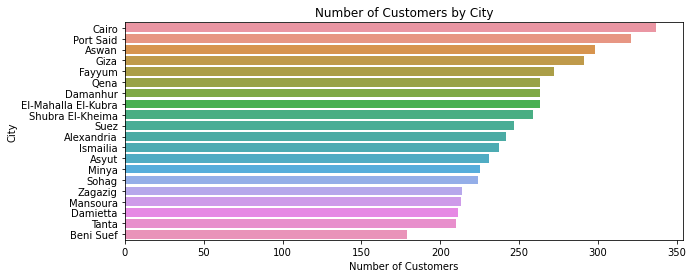

In [29]:
plt.figure(figsize=(10,4))
sns.countplot(data=df, y='city_name', order=df['city_name'].value_counts().index)
plt.title('Number of Customers by City')
plt.xlabel('Number of Customers')
plt.ylabel('City')
plt.show()

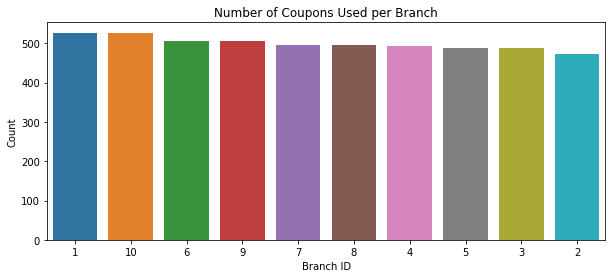

In [30]:
plt.figure(figsize=(10,4))
sns.countplot(data=df, x='branch_id', order=df['branch_id'].value_counts().index)
plt.title('Number of Coupons Used per Branch')
plt.xlabel('Branch ID')
plt.ylabel('Count')
plt.show()

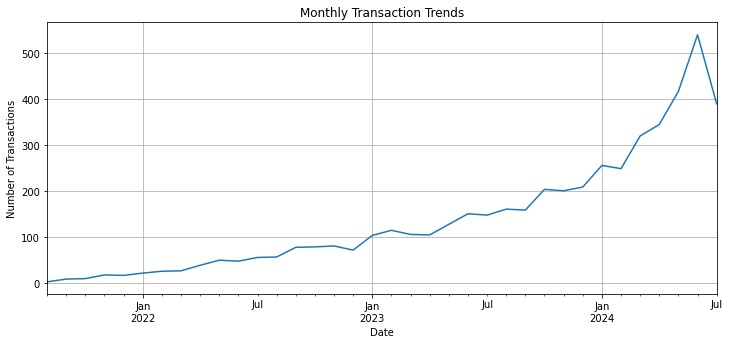

In [32]:
df['transaction_date'] = pd.to_datetime(df['transaction_date'])

monthly_transactions = df.groupby(df['transaction_date'].dt.to_period('M')).size()
monthly_transactions.index = monthly_transactions.index.to_timestamp()

plt.figure(figsize=(12,5))
monthly_transactions.plot()
plt.title('Monthly Transaction Trends')
plt.xlabel('Date')
plt.ylabel('Number of Transactions')
plt.grid(True)
plt.show()

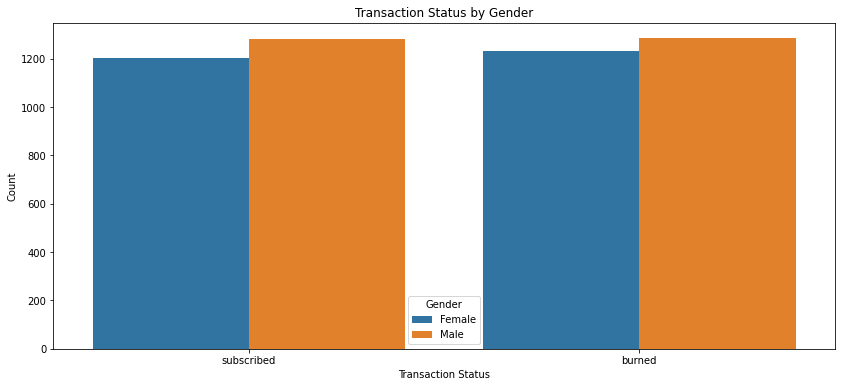

In [33]:
plt.figure(figsize=(14, 6))
sns.countplot(data=df, x='transaction_status', hue='gender_name')
plt.title('Transaction Status by Gender')
plt.xlabel('Transaction Status')
plt.ylabel('Count')
plt.legend(title='Gender')
plt.show()

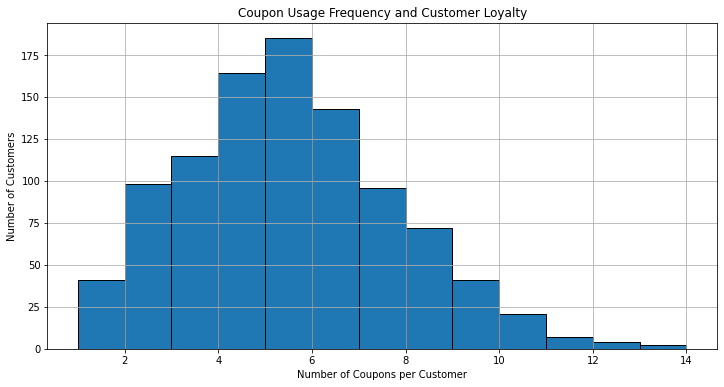

In [34]:
customer_coupon_count = df.groupby('customer_id').size()
plt.figure(figsize=(12, 6))
plt.hist(customer_coupon_count, bins=range(1, customer_coupon_count.max() + 1), edgecolor='black')
plt.xlabel('Number of Coupons per Customer')
plt.ylabel('Number of Customers')
plt.title('Coupon Usage Frequency and Customer Loyalty')
plt.grid(True)
plt.show()

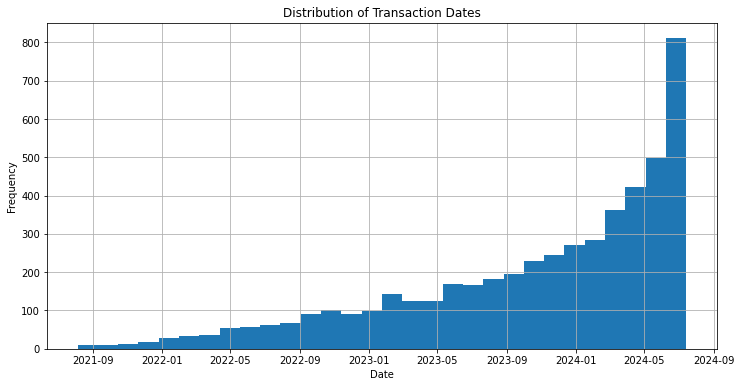

In [35]:
plt.figure(figsize=(12, 6))
df['transaction_date'].dropna().hist(bins=30)
plt.title('Distribution of Transaction Dates')
plt.xlabel('Date')
plt.ylabel('Frequency')
plt.show()

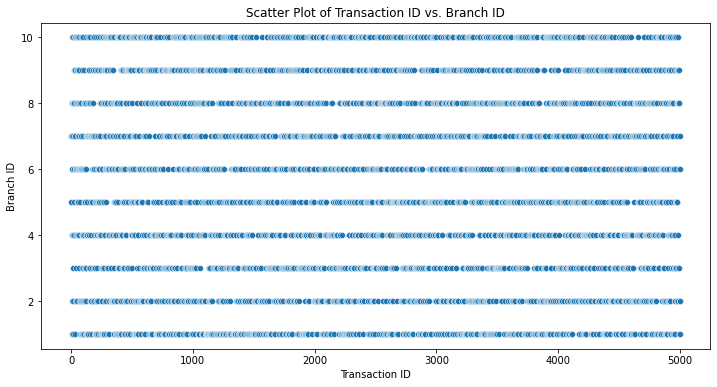

In [36]:
plt.figure(figsize=(12, 6))
sns.scatterplot(data=df, x='transaction_id', y='branch_id')
plt.title('Scatter Plot of Transaction ID vs. Branch ID')
plt.xlabel('Transaction ID')
plt.ylabel('Branch ID')
plt.show()

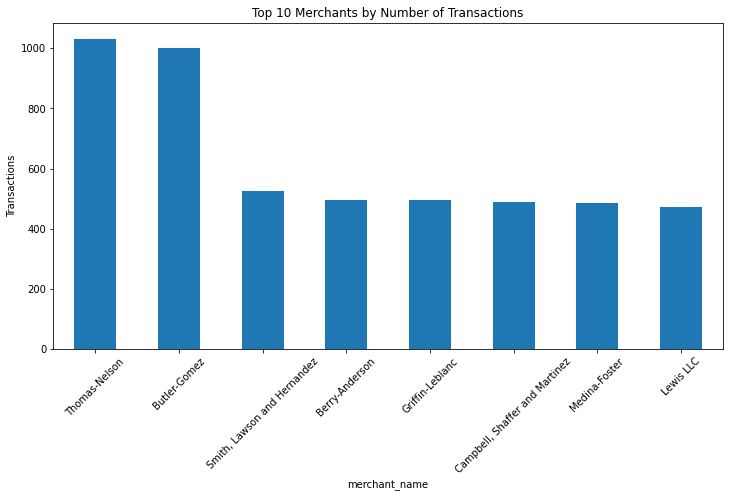

In [39]:
plt.figure(figsize=(12, 6))
df['merchant_name'].value_counts().head(10).plot(kind='bar')
plt.title('Top 10 Merchants by Number of Transactions')
plt.ylabel('Transactions')
plt.xticks(rotation=45)
plt.show()

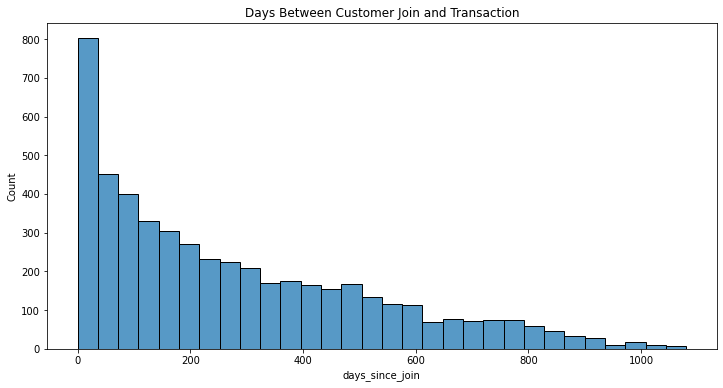

In [43]:
plt.figure(figsize=(12, 6))
df['days_since_join'] = (df['transaction_date'] - df['join_date']).dt.days
sns.histplot(df['days_since_join'], bins=30)
plt.title('Days Between Customer Join and Transaction')
plt.show()

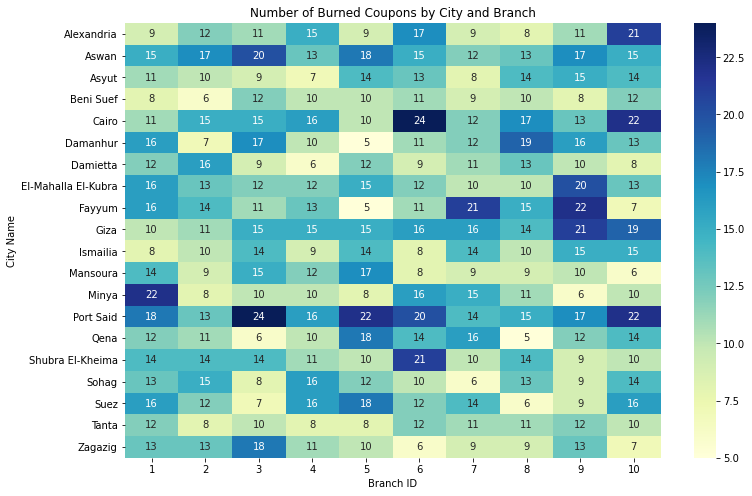

In [44]:
city_branch_burns = df[df['transaction_status'] == 'burned'].groupby(['city_name', 'branch_id']).size().unstack()
plt.figure(figsize=(12, 8))
sns.heatmap(city_branch_burns, cmap='YlGnBu', annot=True, fmt='.0f') 
plt.title('Number of Burned Coupons by City and Branch')
plt.xlabel('Branch ID')
plt.ylabel('City Name')
plt.show()

## Data processing

In [47]:
df['coupon_used'] = df['burn_date'].notnull().astype(int)
df.drop(columns=['burn_date'], inplace=True)

df['transaction_status'] = df['transaction_status'].astype('category')
df['coupon_name'] = df['coupon_name'].astype('category')
df['gender_name'] = df['gender_name'].astype('category')
df['city_name'] = df['city_name'].astype('category')
df['merchant_name'] = df['merchant_name'].astype('category')

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   transaction_id      5000 non-null   int64         
 1   customer_id         5000 non-null   int64         
 2   transaction_date    5000 non-null   datetime64[ns]
 3   transaction_status  5000 non-null   category      
 4   coupon_name         5000 non-null   category      
 5   branch_id           5000 non-null   int64         
 6   join_date           5000 non-null   datetime64[ns]
 7   city_id             5000 non-null   int64         
 8   gender_id           5000 non-null   int64         
 9   gender_name         5000 non-null   category      
 10  city_name           5000 non-null   category      
 11  merchant_id         5000 non-null   int64         
 12  merchant_name       5000 non-null   category      
 13  days_since_join     5000 non-null   int64       

In [49]:
features = ['coupon_used', 'days_since_join']  

In [50]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[features])

## KMeans

C:\Users\Right-click\anaconda3\anaconda\lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
C:\Users\Right-click\anaconda3\anaconda\lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
C:\Users\Right-click\anaconda3\anaconda\lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
C:\Users\Right-click\anaconda3\anaconda\lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_

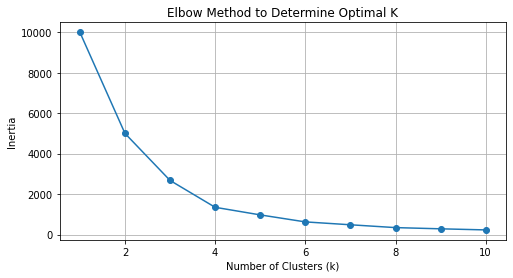

In [51]:
from sklearn.cluster import KMeans

inertia = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,4))
plt.plot(k_range, inertia, marker='o')
plt.title('Elbow Method to Determine Optimal K')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.grid(True)
plt.show()

In [52]:
kmeans = KMeans(n_clusters=3, random_state=42)
df['cluster'] = kmeans.fit_predict(X_scaled)

C:\Users\Right-click\anaconda3\anaconda\lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


In [54]:
df.groupby('cluster')[features].mean()

,coupon_used,days_since_join
cluster,,
0,0.000000,177.006533
1,1.000000,172.292067
2,0.520854,668.960233


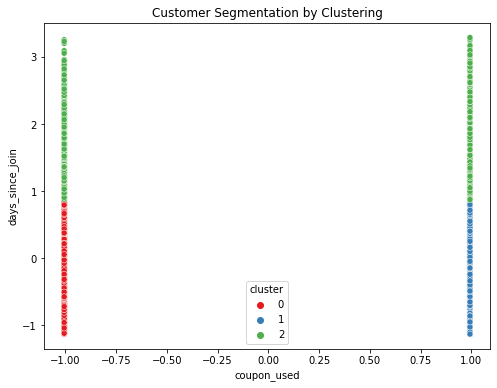

In [55]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=X_scaled[:,0], y=X_scaled[:,1], hue=df['cluster'], palette='Set1')
plt.title('Customer Segmentation by Clustering')
plt.xlabel(features[0])
plt.ylabel(features[1])
plt.show()

In [57]:
from sklearn.metrics import silhouette_score

score = silhouette_score(X_scaled, df['cluster'])
print(f"Silhouette Score: {score:.4f}")

Silhouette Score: 0.5879


## DBSCAN

In [58]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=0.5, min_samples=5)
df['dbscan_cluster'] = dbscan.fit_predict(X_scaled)

In [59]:
print(df['dbscan_cluster'].value_counts())

dbscan_cluster
1    2516
0    2484
Name: count, dtype: int64


In [62]:
labels = df['dbscan_cluster']

n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = list(labels).count(-1)

print(f"Number of clusters found (excluding noise): {n_clusters}")
print(f"Number of noise points: {n_noise}")

if n_clusters > 1:
    score = silhouette_score(X_scaled[labels != -1], labels[labels != -1])
    print(f"Silhouette Score (excluding noise): {score:.4f}")
else:
    print(" Not enough clusters to compute Silhouette Score.")

Number of clusters found (excluding noise): 2
Number of noise points: 0
Silhouette Score (excluding noise): 0.5519


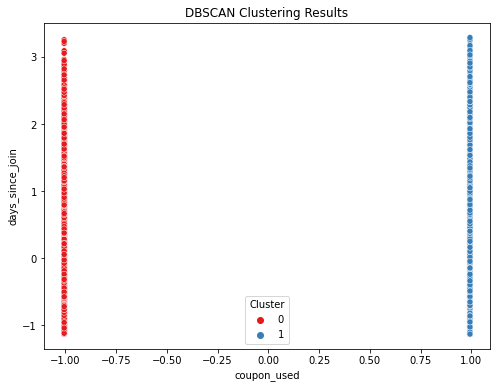

In [61]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=X_scaled[:,0], y=X_scaled[:,1], hue=df['dbscan_cluster'], palette='Set1')
plt.title('DBSCAN Clustering Results')
plt.xlabel(features[0])
plt.ylabel(features[1])
plt.legend(title='Cluster')
plt.show()

## Hierarchical

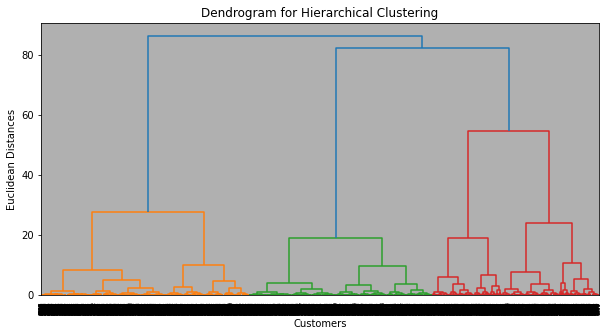

In [63]:
import scipy.cluster.hierarchy as sch

plt.figure(figsize=(10, 5))
dendrogram = sch.dendrogram(sch.linkage(X_scaled, method='ward'))
plt.title('Dendrogram for Hierarchical Clustering')
plt.xlabel('Customers')
plt.ylabel('Euclidean Distances')
plt.grid(True)
plt.show()

In [64]:
from sklearn.cluster import AgglomerativeClustering

hc = AgglomerativeClustering(n_clusters=2, affinity='euclidean', linkage='ward')
df['hc_cluster'] = hc.fit_predict(X_scaled)

C:\Users\Right-click\anaconda3\anaconda\lib\site-packages\sklearn\cluster\_agglomerative.py:1006: FutureWarning: Attribute `affinity` was deprecated in version 1.2 and will be removed in 1.4. Use `metric` instead
  warnings.warn(


In [65]:
df['hc_cluster'].value_counts()

hc_cluster
0    3132
1    1868
Name: count, dtype: int64

In [66]:
df.groupby('hc_cluster')[features].mean()


,coupon_used,days_since_join
hc_cluster,,
0,0.803321,347.154534
1,0.000000,158.254283


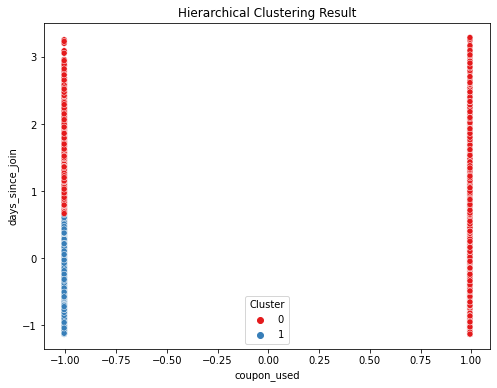

In [67]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=X_scaled[:, 0], y=X_scaled[:, 1], hue=df['hc_cluster'], palette='Set1')
plt.title('Hierarchical Clustering Result')
plt.xlabel(features[0])
plt.ylabel(features[1])
plt.legend(title='Cluster')
plt.show()

In [68]:
from sklearn.metrics import silhouette_score

score = silhouette_score(X_scaled, df['hc_cluster'])
print(f"Silhouette Score: {score:.4f}")

Silhouette Score: 0.4510


## Comparison of results perceptions

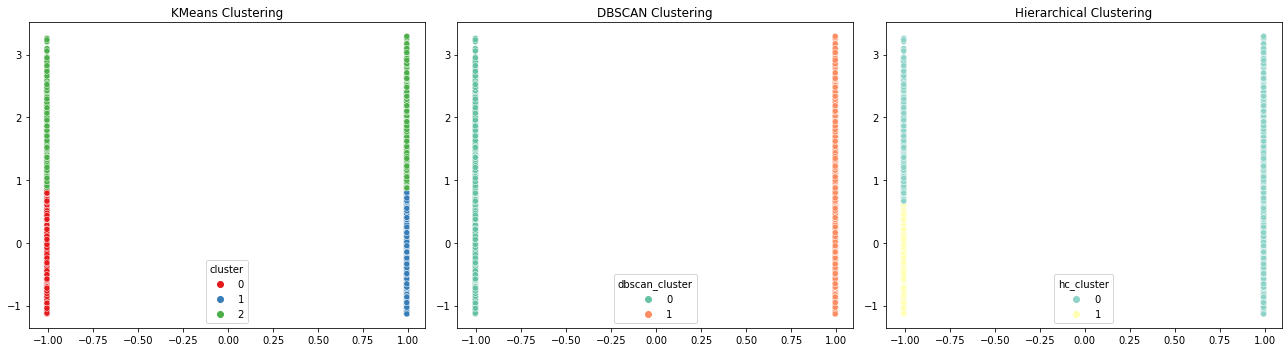

In [71]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# KMeans
sns.scatterplot(ax=axes[0], x=X_scaled[:,0], y=X_scaled[:,1], hue=df['cluster'], palette='Set1')
axes[0].set_title('KMeans Clustering')

# DBSCAN
sns.scatterplot(ax=axes[1], x=X_scaled[:,0], y=X_scaled[:,1], hue=df['dbscan_cluster'], palette='Set2')
axes[1].set_title('DBSCAN Clustering')

# Hierarchical
sns.scatterplot(ax=axes[2], x=X_scaled[:,0], y=X_scaled[:,1], hue=df['hc_cluster'], palette='Set3')
axes[2].set_title('Hierarchical Clustering')

plt.tight_layout()
plt.show()